# Before you start:
- Read the README.md file
- Comment as much as you can and use the resources (README.md file)
- Happy learning!

In [1]:
# import numpy and pandas

import numpy as np
import pandas as pd

from statsmodels.stats.weightstats import ztest
from scipy import stats

import seaborn as sns
import matplotlib.pylab as plt

# Challenge 1 - Exploring the Data

In this challenge, we will examine all salaries of employees of the City of Chicago. We will start by loading the dataset and examining its contents. Please, load the data using Ironhack's database (db: employees, table: employees_advanced).

In [2]:
# Your code here:

employees = pd.read_csv('../data/Current_Employee_Names__Salaries__and_Position_Titles.csv')

Examine the `salaries` dataset using the `head` function below.

In [3]:
# Your code here:

employees.head()

,Name,Job Titles,Department,Full or Part-Time,Salary or Hourly,Typical Hours,Annual Salary,Hourly Rate
0,"AARON, JEFFERY M",SERGEANT,POLICE,F,Salary,NaN,101442.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),POLICE,F,Salary,NaN,94122.0,NaN
2,"AARON, KIMBERLEI R",CHIEF CONTRACT EXPEDITER,GENERAL SERVICES,F,Salary,NaN,101592.0,NaN
3,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,WATER MGMNT,F,Salary,NaN,110064.0,NaN
4,"ABASCAL, REECE E",TRAFFIC CONTROL AIDE-HOURLY,OEMC,P,Hourly,20.0,NaN,19.86


We see from looking at the `head` function that there is quite a bit of missing data. Let's examine how much missing data is in each column. Produce this output in the cell below

In [4]:
# Your code here:

employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33183 entries, 0 to 33182
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               33183 non-null  object 
 1   Job Titles         33183 non-null  object 
 2   Department         33183 non-null  object 
 3   Full or Part-Time  33183 non-null  object 
 4   Salary or Hourly   33183 non-null  object 
 5   Typical Hours      8022 non-null   float64
 6   Annual Salary      25161 non-null  float64
 7   Hourly Rate        8022 non-null   float64
dtypes: float64(3), object(5)
memory usage: 2.0+ MB


Let's also look at the count of hourly vs. salaried employees. Write the code in the cell below

In [5]:
# Your code here:
hourly_emp = employees[employees['Salary or Hourly'] == 'Hourly']
salaried_emp = employees[employees['Salary or Hourly'] == 'Salary']

print(f'Number of Hourly employees: {len(hourly_emp.index)}\nNumber of Salaried employees: {len(salaried_emp.index)}')

# Alternative employees['Salary or Hourly'].value_counts()

Number of Hourly employees: 8022
Number of Salaried employees: 25161


What this information indicates is that the table contains information about two types of employees - salaried and hourly. Some columns apply only to one type of employee while other columns only apply to another kind. This is why there are so many missing values. Therefore, we will not do anything to handle the missing values.

There are different departments in the city. List all departments and the count of employees in each department.

In [6]:
# Your code here:

pivot_table = employees.pivot_table(index='Department', values='Name', aggfunc='count').sort_values(by="Name", ascending=False)

pivot_table

#Alternatives:
# employees.groupby('Department').count()["Name"]
# employees['Department'].value_counts()


,Name
Department,
POLICE,13414
FIRE,4641
STREETS & SAN,2198
OEMC,2102
WATER MGMNT,1879
AVIATION,1629
TRANSPORTN,1140
PUBLIC LIBRARY,1015
GENERAL SERVICES,980


# Challenge 2 - Hypothesis Tests

In this section of the lab, we will test whether the hourly wage of all hourly workers is significantly different from $30/hr. Import the correct one sample test function from scipy and perform the hypothesis test for a 95% two sided confidence interval.

In [7]:
# Your code here:
'''
1. Hipothesis definition:

Ho = Hourly Rate mean = 30
H1 = Hourly Rete mean != 30

2. Define Alpha:

alpha = 1 - 0,95 => 0,05/2 => 0,025

3. Hipothesis test:
'''
hypothesis_mean = 30

Z_score, p_value = ztest(hourly_emp['Hourly Rate'], value=hypothesis_mean)

print(f'Z_score: {Z_score}', f'\np-value: {p_value}')


'''
4. Accept/Reject Ho and conclusion:

Given that p-value is below alpha, we reject Ho.
This means that the hourly wage of all hourly workers is significantly different from $30/hr. 
'''

Z_score: 20.6198057854942 
p-value: 1.8228873859286195e-94


'\n4. Accept/Reject Ho and conclusion:\n\nGiven that p-value is below alpha, we reject Ho.\nThis means that the hourly wage of all hourly workers is significantly different from $30/hr. \n'

We are also curious about salaries in the police force. The chief of police in Chicago claimed in a press briefing that salaries this year are higher than last year's mean of $86000/year a year for all salaried employees. Test this one sided hypothesis using a 95% confidence interval.

Hint: A one tailed test has a p-value that is half of the two tailed p-value. If our hypothesis is greater than, then to reject, the test statistic must also be positive.

In [8]:
# Your code here:

'''
1. Hipothesis definition:

Ho = Salaries mean < 86.000
H1 = Salaries mean >= 86.000

2. Define Alpha: 

alpha = 1 - 0,95 => 0,05

3. Hipothesis test:
'''
hypothesis_mean = 86000

salaries_police = salaried_emp[salaried_emp['Department'] == 'POLICE']

Z_score, p_value = ztest(salaries_police['Annual Salary'], value=hypothesis_mean)

this_year_mean = salaries_police['Annual Salary'].mean()

print(f'Z_score: {Z_score}', f'\np-value: {p_value}', f'\nCurrent Year Salary Mean: {this_year_mean}')

'''
4. Accept/Reject Ho and conclusion:

Given that p-value is below alpha we reject Ho.
This means that we cannot contradict the claim from chief of police in Chicago.
'''

Z_score: 3.081997005712994 
p-value: 0.002056169057509571 
Current Year Salary Mean: 86486.41450313339


'\n4. Accept/Reject Ho and conclusion:\n\nGiven that p-value is below alpha we reject Ho.\nThis means that we cannot contradict the claim from chief of police in Chicago.\n'

Using the `crosstab` function, find the department that has the most hourly workers. 

In [9]:
# Your code here:

crosstab = pd.crosstab(employees['Department'], employees['Salary or Hourly'])

crosstab

# The department with the highest number of hourly workers is STREETS & SAN


Salary or Hourly,Hourly,Salary
Department,,
ADMIN HEARNG,0,39
ANIMAL CONTRL,19,62
AVIATION,1082,547
BOARD OF ELECTION,0,107
BOARD OF ETHICS,0,8
BUDGET & MGMT,2,44
BUILDINGS,0,269
BUSINESS AFFAIRS,7,164
CITY CLERK,0,84


The workers from the department with the most hourly workers have complained that their hourly wage is less than $35/hour. Using a one sample t-test, test this one-sided hypothesis at the 95% confidence level.

In [10]:
# Your code here:

'''
1. Hipothesis definition:

Ho = Hourly Rate mean > 35
H1 = Hourly Rate mean <= 35

2. Define Alpha: 

alpha = 1 - 0,95 => 0,05

3. Hipothesis test:
'''
hypothesis_mean = 35

hrate_streetsandsan = hourly_emp[hourly_emp['Department'] == 'STREETS & SAN']

Z_score, p_value = ztest(hrate_streetsandsan['Hourly Rate'], value=hypothesis_mean)

hrate_streetsandsan_mean = hrate_streetsandsan['Hourly Rate'].mean()

print(f'Z_score: {Z_score}', f'\np-value: {p_value}', f'\nCurrent Year Salary Mean: {hrate_streetsandsan_mean}')

'''
4. Accept/Reject Ho and conclusion:

Given that p-value is below alpha we reject Ho.
This means that we cannot contradict the claim from STREETS & SAN workers.
'''

Z_score: -9.567447887848152 
p-value: 1.0957711283886869e-21 
Current Year Salary Mean: 33.72837808807734


'\n4. Accept/Reject Ho and conclusion:\n\nGiven that p-value is below alpha we reject Ho.\nThis means that we cannot contradict the claim from STREETS & SAN workers.\n'

# Challenge 3: To practice - Constructing Confidence Intervals

While testing our hypothesis is a great way to gather empirical evidence for accepting or rejecting the hypothesis, another way to gather evidence is by creating a confidence interval. A confidence interval gives us information about the true mean of the population. So for a 95% confidence interval, we are 95% sure that the mean of the population is within the confidence interval. 
).

To read more about confidence intervals, click [here](https://en.wikipedia.org/wiki/Confidence_interval).


In the cell below, we will construct a 95% confidence interval for the mean hourly wage of all hourly workers. 

The confidence interval is computed in SciPy using the `t.interval` function. You can read more about this function [here](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.t.html).

To compute the confidence interval of the hourly wage, use the 0.95 for the confidence level, number of rows - 1 for degrees of freedom, the mean of the sample for the location parameter and the standard error for the scale. The standard error can be computed using [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html) function in SciPy.

In [ ]:
'''What is a Confidence Interval?
A Confidence Interval (CI) is a range of values that is used to estimate an unknown population parameter
(like the mean or average) with a certain level of confidence. It tells you how precise your estimate is,
based on the data you have collected.

Imagine you are trying to estimate something about a larger group (the population) based on a smaller group (a sample).

For example:

You want to know the average height of all people in a city.
You can’t measure everyone, so you take a sample of 100 people and calculate their average height.
But the true average height of all people in the city could be different from the sample average.
The confidence interval helps you say, "We are fairly sure the true average height lies within this range."'''

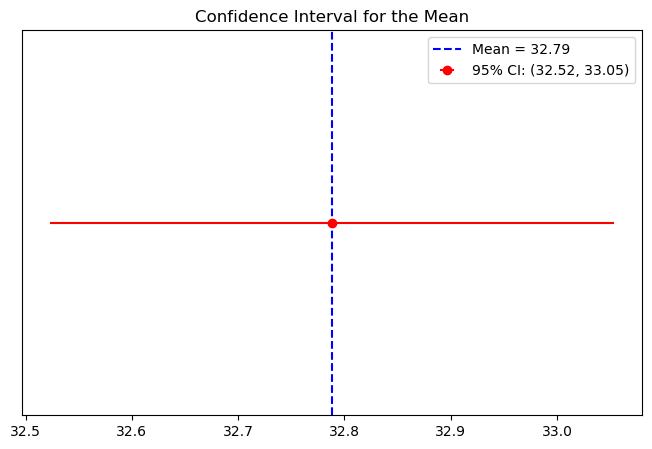

In [13]:
# Your code here:

# Sample data:
data = hourly_emp['Hourly Rate']

# Calculate the sample mean and standard error
mean = hourly_emp['Hourly Rate'].mean()
std_error = stats.sem(data)

# Confidence Level: 95%
confidence_level = 0.95

# Calculate the margin of error
confidence_interval = stats.t.interval(confidence_level, len(data)-1, loc=mean, scale=std_error)

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(mean, 0, xerr=[[mean - confidence_interval[0]], [confidence_interval[1] - mean]], fmt='o', color='red', label=f'95% CI: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})')

plt.title('Confidence Interval for the Mean')
plt.yticks([])  # Hide y-axis ticks
plt.axvline(mean, color='blue', linestyle='dashed', label=f'Mean = {mean:.2f}')
plt.legend()
plt.show()

Now construct the 95% confidence interval for all salaried employeed in the police in the cell below.

In [13]:
# Your code here:



# Bonus Challenge - Hypothesis Tests of Proportions

Another type of one sample test is a hypothesis test of proportions. In this test, we examine whether the proportion of a group in our sample is significantly different than a fraction. 

You can read more about one sample proportion tests [here](http://sphweb.bumc.bu.edu/otlt/MPH-Modules/BS/SAS/SAS6-CategoricalData/SAS6-CategoricalData2.html).

In the cell below, use the `proportions_ztest` function from `statsmodels` to perform a hypothesis test that will determine whether the number of hourly workers in the City of Chicago is significantly different from 25% at the 95% confidence level.

In [18]:
# Your code here:

'''
1. Hipothesis definition:

Ho = The proportion of hourly workers is 25%
H1 = The proportion of hourly workers is different from 25%.

2. Define Alpha: 

alpha = 1 - 0,95 => 0,05

3. Hipothesis test:
'''

from statsmodels.stats.proportion import proportions_ztest

# Sample data

hrate_streetsandsan = hourly_emp[hourly_emp['Department'] == 'STREETS & SAN']
n = len(employees.index)  # Sample size
x = len(hourly_emp.index)  # Number of hourly workers (successes)
print(f'The weight of hourly_emp is: {x/n*100:.2f}%')
p_null = 0.25  # Hypothesized proportion of hourly workers

# Perform the z-test
z_stat, p_value = proportions_ztest(x, n, value=p_null, alternative='two-sided')

# Print the result
print(f"Z-statistic: {z_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# Decision based on p-value
alpha = 0.05  # 95% confidence level
if p_value < alpha:
    print("Reject the null hypothesis: The proportion of hourly workers is significantly different from 25%.")
else:
    print("Fail to reject the null hypothesis: The proportion of hourly workers is not significantly different from 25%.")


The weight of hourly_emp is: 24.18%
Z-statistic: -3.51
P-value: 0.0004
Reject the null hypothesis: The proportion of hourly workers is significantly different from 25%.
